# Optymalizacja Portfela Inwestycyjnego
## Redukcja uniwersum przez k-means + optymalizacja reprezentantów algorytmem genetycznym

**Kurs:** Matematyczne Podstawy Sztucznej Inteligencji (MPSI), Uniwersytet Jagielloński &nbsp;·&nbsp;
**Autor:** Karol &nbsp;·&nbsp; **Notebook:** kod + raport w jednym pliku

---

### Streszczenie

Z dużego uniwersum **~186 spółek S&P 500** budujemy optymalny portfel maksymalizujący **wskaźnik Sharpe'a**.
Bezpośrednia optymalizacja 186 wag jest niepraktyczna i niestabilna (wiele spółek to bliskie duplikaty o
wysokiej korelacji). Dlatego stosujemy **redukcję wymiarowości grupowaniem k-means**:

1. **k-means** (od zera) grupuje 186 spółek wg profilu ryzyko–zwrot $(\mu,\sigma)$ i wyłania **reprezentantów**
   klastrów — zróżnicowany, nieskorelowany podzbiór.
2. **Monte Carlo** eksploruje przestrzeń portfeli reprezentantów (granica efektywna Markowitza).
3. **Algorytm genetyczny** (od zera) optymalizuje wagi **wyłącznie reprezentantów**, maksymalizując Sharpe'a.

Wynik walidujemy analitycznym solverem **SLSQP** (ground truth) i badamy **wrażliwość GA na hiperparametry**
w **11 eksperymentach** (każdy uśredniony po 5 ziarnach losowych).

> **Najważniejszy wynik:** k-means redukuje 186 → 22 reprezentantów; na tym podzbiorze algorytm genetyczny
> osiąga ~**98%** optimum analitycznego, podczas gdy losowe próbkowanie Monte Carlo (przy tym samym budżecie
> obliczeniowym) tylko ~**77%**. To pokazuje wartość *obu* technik: klasteryzacji do redukcji uniwersum
> i ukierunkowanej ewolucji do optymalizacji.

## 1. Wprowadzenie i cel

### 1.1. Problem

Dysponujemy uniwersum $N\approx186$ aktywów. Szukamy wektora wag $\mathbf{w}$ maksymalizującego Sharpe'a:

$$\max_{\mathbf w}\ \frac{\mathbf{w}^\top\boldsymbol{\mu}-R_f}{\sqrt{\mathbf{w}^\top\boldsymbol{\Sigma}\mathbf{w}}}
\qquad \text{przy}\qquad \sum_i w_i=1,\ \ w_i\ge 0.$$

Optymalizacja na **sympleksie** w 186 wymiarach jest źle uwarunkowana: macierz kowariancji jest niemal
osobliwa (spółki z tego samego sektora są silnie skorelowane), a przestrzeń zbyt duża, by ją przeszukać.

### 1.2. Pomysł: redukcja przez grupowanie

Zamiast optymalizować wszystkie 186 spółek, najpierw **grupujemy** je k-means w przestrzeni ryzyko–zwrot
i z każdego klastra wybieramy **jednego reprezentanta** (spółkę najbliższą centroidowi). Otrzymujemy
zróżnicowany, słabo skorelowany podzbiór $k$ aktywów — i to **tylko jego wagi** optymalizujemy.

| Etap | Technika | Rola |
|------|----------|------|
| 1 | **k-means** (od zera) | Redukcja 186 → $k$ reprezentantów wg profilu $(\mu,\sigma)$ |
| 2 | **Monte Carlo** | Eksploracja, granica efektywna, *baseline* losowy |
| 3 | **Algorytm genetyczny** (od zera) | Optymalizacja wag $k$ reprezentantów $\to\max$ Sharpe |
| — | **SLSQP** (scipy) | *Ground truth* — walidacja jakości rozwiązania GA |

### 1.3. Dlaczego to działa (i dlaczego GA, a nie Monte Carlo)

Klasteryzacja czyni problem **tractable i dobrze uwarunkowanym**: $k\approx22$ słabo skorelowanych aktywów
zamiast 186. Mimo to przestrzeń $k$-wymiarowa wciąż jest zbyt duża dla ślepego losowania — jak pokażemy,
Monte Carlo przy 30 000 prób osiąga tylko ~77% optimum, podczas gdy GA ~98%. To uzasadnia *oba* kroki:
k-means redukuje, GA optymalizuje.

### 1.4. Reprodukowalność

Wszystkie losowania mają ustalone ziarno (`SEED = 42`). Dane są cache'owane do `prices.csv`, więc wyniki są
identyczne przy każdym uruchomieniu (i offline po pierwszym pobraniu).

In [1]:
# --- Konfiguracja środowiska, uniwersum spółek i styl wykresów ---
import warnings; warnings.filterwarnings("ignore")
import os, time, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from IPython.display import display

%matplotlib inline

SEED         = 42          # ziarno dla pełnej reprodukowalności
RF           = 0.04        # roczna stopa wolna od ryzyka
TRADING_DAYS = 252         # dni giełdowe w roku (annualizacja)
START, END   = "2021-01-01", "2024-01-01"

# Uniwersum: ~186 spółek S&P 500 pogrupowanych wg sektorów GICS
SECTOR_GROUPS = {
 "Information Technology": ["AAPL","MSFT","NVDA","AVGO","ADBE","CRM","ORCL","CSCO","ACN","INTC","AMD","TXN","QCOM","IBM","INTU","NOW","AMAT","LRCX","MU","ADI","KLAC","SNPS","CDNS","ANET","FTNT","PANW"],
 "Communication Services": ["GOOGL","META","NFLX","DIS","CMCSA","VZ","T","TMUS","CHTR","EA","TTWO","OMC"],
 "Consumer Discretionary": ["AMZN","TSLA","HD","MCD","NKE","LOW","SBUX","BKNG","TJX","GM","F","ORLY","AZO","ROST","YUM","MAR","HLT","CMG","DG","DLTR"],
 "Consumer Staples": ["WMT","PG","KO","PEP","COST","MDLZ","CL","MO","PM","TGT","KHC","GIS","HSY","STZ","KMB","SYY","ADM","KR"],
 "Health Care": ["UNH","JNJ","LLY","PFE","MRK","ABBV","TMO","ABT","DHR","BMY","AMGN","CVS","MDT","GILD","ISRG","VRTX","REGN","ZTS","BSX","HCA","CI","HUM"],
 "Financials": ["JPM","BAC","WFC","GS","MS","C","AXP","BLK","SCHW","SPGI","CB","USB","PNC","TFC","COF","MET","PRU","AIG","TRV","AON","MMC","ICE","CME","PYPL"],
 "Energy": ["XOM","CVX","COP","SLB","EOG","MPC","PSX","OXY","VLO","KMI","WMB","HAL","DVN"],
 "Industrials": ["CAT","BA","HON","UPS","GE","RTX","LMT","DE","UNP","MMM","EMR","CSX","NSC","FDX","ETN","ITW","PH","GD","NOC","WM","RSG"],
 "Materials": ["LIN","APD","SHW","FCX","NEM","ECL","NUE","DD","PPG"],
 "Utilities": ["NEE","DUK","SO","D","AEP","SRE","XEL","ED","PEG","WEC","ES"],
 "Real Estate": ["AMT","PLD","CCI","SPG","O","PSA","EQIX","DLR","AVB","EQR","WELL"],
}
TICKERS = sorted({t for g in SECTOR_GROUPS.values() for t in g})
SECTOR  = {t: s for s, g in SECTOR_GROUPS.items() for t in g}

# Paleta sektorowa (11 sektorów) + styl
SECTOR_COLORS = dict(zip(SECTOR_GROUPS.keys(),
    ["#2563eb","#dc2626","#16a34a","#ea580c","#7c3aed","#0891b2","#ca8a04","#db2777","#0d9488","#9333ea","#65a30d"]))
plt.rcParams.update({
    "figure.figsize": (11, 6), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "font.size": 10, "legend.fontsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
})

print("numpy", np.__version__, "| pandas", pd.__version__, "| Python", sys.version.split()[0])
print(f"Uniwersum: {len(TICKERS)} spółek z {len(SECTOR_GROUPS)} sektorów | okres {START} -> {END} | RF = {RF:.0%}")

numpy 2.4.3 | pandas 3.0.3 | Python 3.14.2
Uniwersum: 187 spółek z 11 sektorów | okres 2021-01-01 -> 2024-01-01 | RF = 4%


## 2. Dane

### 2.1. Źródło

Dzienne ceny zamknięcia z **Yahoo Finance** (`yfinance`), skorygowane o dywidendy i splity (`auto_adjust=True`).
Pobieramy raz i cache'ujemy do `prices.csv`. Spółki z brakami danych w oknie są usuwane (`dropna`).

### 2.2. Logarytmiczne stopy zwrotu i annualizacja

$$r_t=\ln\!\frac{P_t}{P_{t-1}},\qquad
\mu_{\text{rok}}=252\,\overline{r},\quad
\Sigma_{\text{rok}}=252\,\widehat{\Sigma},\quad
\sigma_{\text{rok}}=\sqrt{252}\,s_r.$$

Log-zwroty są addytywne w czasie i bliższe rozkładowi normalnego (założenie modelu Markowitza).

### 2.3. Uniwersum

~186 dużych spółek S&P 500 ze wszystkich 11 sektorów GICS — szeroki przekrój profili ryzyko–zwrot,
co jest warunkiem sensownego grupowania.

In [2]:
# --- Pobranie / wczytanie danych (z cache) ---
CACHE = os.path.join(os.getcwd(), "prices.csv")

def load_prices():
    if os.path.exists(CACHE):
        return pd.read_csv(CACHE, index_col=0, parse_dates=True), "cache (prices.csv)"
    import yfinance as yf
    raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
    df = raw["Close"].dropna(axis=1, how="any")
    df.to_csv(CACHE)
    return df, "yfinance (online)"

prices, DATA_SOURCE = load_prices()
tickers = list(prices.columns)

returns   = np.log(prices / prices.shift(1)).dropna()
mu_vec    = returns.mean() * TRADING_DAYS                 # roczny zwrot, Series
sigma_vec = returns.std() * np.sqrt(TRADING_DAYS)         # roczne ryzyko, Series
cov_mat   = returns.cov() * TRADING_DAYS                  # roczna kowariancja, DataFrame

sec_counts = pd.Series([SECTOR[t] for t in tickers]).value_counts()
print(f"Źródło danych  : {DATA_SOURCE}")
print(f"Spółek użytych : {len(tickers)} (z {len(TICKERS)} zamówionych)")
print(f"Dni giełdowych : {len(returns)}  ({returns.index.min().date()} -> {returns.index.max().date()})")
print(f"Zwrot mu       : {mu_vec.min():+.1%} .. {mu_vec.max():+.1%}")
print(f"Ryzyko sigma   : {sigma_vec.min():.1%} .. {sigma_vec.max():.1%}")
print("\nSpółek na sektor:"); print(sec_counts.to_string())

Źródło danych  : cache (prices.csv)
Spółek użytych : 186 (z 187 zamówionych)
Dni giełdowych : 752  (2021-01-05 -> 2023-12-29)
Zwrot mu       : -44.5% .. +46.3%
Ryzyko sigma   : 16.2% .. 58.9%

Spółek na sektor:
Information Technology    26
Financials                23
Health Care               22
Industrials               21
Consumer Discretionary    20
Consumer Staples          18
Energy                    13
Communication Services    12
Utilities                 11
Real Estate               11
Materials                  9


5 najlepszych i 5 najgorszych spółek wg indywidualnego Sharpe:


,Sektor,mu (%),sigma (%),Sharpe
LLY,Health Care,43.5,28.9,1.366
MPC,Energy,46.3,33.0,1.283
COP,Energy,40.0,36.3,0.993
XOM,Energy,33.9,30.2,0.990
AVGO,Information Technology,35.1,32.7,0.953
CHTR,Communication Services,-17.1,33.3,-0.632
VZ,Communication Services,-9.3,20.4,-0.652
D,Utilities,-11.0,22.2,-0.675
DIS,Communication Services,-22.6,30.1,-0.882
PYPL,Financials,-44.5,46.0,-1.056


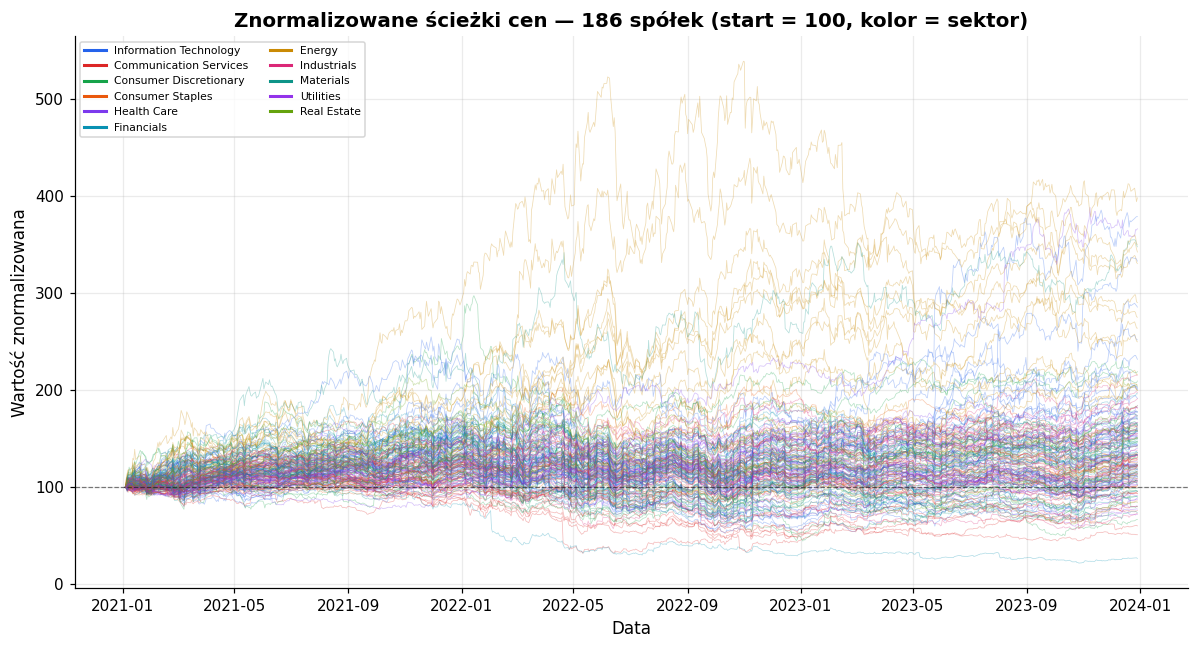

In [3]:
# --- Przegląd: ekstrema wg Sharpe + znormalizowane ścieżki cen (kolor = sektor) ---
indiv = pd.DataFrame({
    "Sektor": [SECTOR[t] for t in tickers],
    "mu (%)": (mu_vec * 100).round(1),
    "sigma (%)": (sigma_vec * 100).round(1),
    "Sharpe": ((mu_vec - RF) / sigma_vec).round(3),
})
print("5 najlepszych i 5 najgorszych spółek wg indywidualnego Sharpe:")
display(pd.concat([indiv.sort_values("Sharpe", ascending=False).head(5),
                   indiv.sort_values("Sharpe", ascending=False).tail(5)]))

fig, ax = plt.subplots(figsize=(11, 6))
norm = prices / prices.iloc[0] * 100
for t in tickers:
    ax.plot(norm.index, norm[t], lw=0.5, alpha=0.30, color=SECTOR_COLORS[SECTOR[t]])
handles = [Line2D([0],[0], color=c, lw=2) for c in SECTOR_COLORS.values()]
ax.legend(handles, SECTOR_COLORS.keys(), ncol=2, loc="upper left", fontsize=7)
ax.set_title(f"Znormalizowane ścieżki cen — {len(tickers)} spółek (start = 100, kolor = sektor)")
ax.set_xlabel("Data"); ax.set_ylabel("Wartość znormalizowana")
ax.axhline(100, color="black", lw=0.8, ls="--", alpha=0.5)
plt.tight_layout(); plt.show()

## 3. Etap 1 — Grupowanie k-średnich (od zera) i redukcja uniwersum

### 3.1. Cel

Reprezentujemy każdą spółkę punktem $(\mu_i,\sigma_i)$ i grupujemy k-means. Z każdego klastra wybieramy
**reprezentanta** (spółkę najbliższą centroidowi) — tak redukujemy 186 spółek do $k$ zróżnicowanych aktywów.

### 3.2. Funkcja kosztu (WCSS) i algorytm

$$J=\sum_{i=1}^{N}\lVert x_i-c_{a_i}\rVert^2,\qquad a_i=\arg\min_j\lVert x_i-c_j\rVert^2.$$

1. **k-means++**: pierwszy centroid losowo, kolejne z $P(x_i)\propto D(x_i)^2$ (rozrzuca centroidy).
2. **Przypisanie** punktów do najbliższych centroidów.
3. **Aktualizacja** centroidów jako średnich klastrów.
4. Powtarzaj 2–3 do zbieżności ($J$ maleje monotonicznie).

### 3.3. Dobór $k$ — Silhouette

$$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}\in[-1,1],$$

$a(i)$ — średnia odległość wewnątrz klastra, $b(i)$ — do najbliższego obcego klastra. Wybieramy $k$
maksymalizujące średni Silhouette. Cechy standaryzujemy ($z=(x-\bar x)/s$), bo $\mu$ i $\sigma$ mają różne skale.

In [4]:
# --- k-means, k-means++, Silhouette, StandardScaler: od zera (tylko NumPy) ---
def standardize(X):
    '''StandardScaler od zera: z = (x - mean) / std.'''
    mean, std = X.mean(axis=0), X.std(axis=0)
    return (X - mean) / std, mean, std

def kpp_init(X, k, rng):
    '''Inicjalizacja k-means++: P(x) ~ D(x)^2.'''
    centroids = [X[rng.integers(len(X))]]
    for _ in range(k - 1):
        d2 = np.array([min(np.sum((x - c)**2) for c in centroids) for x in X])
        centroids.append(X[rng.choice(len(X), p=d2 / d2.sum())])
    return np.array(centroids)

def kmeans(X, k, rng, max_iters=300, tol=1e-9):
    '''k-means (Lloyd). Zwraca centroidy, etykiety, inercję (WCSS).'''
    C = kpp_init(X, k, rng); labels = np.zeros(len(X), dtype=int)
    for _ in range(max_iters):
        D = np.linalg.norm(X[:, None, :] - C[None, :, :], axis=2)
        labels = D.argmin(axis=1)
        newC = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else C[j]
                         for j in range(k)])
        if np.max(np.linalg.norm(newC - C, axis=1)) < tol:
            C = newC; break
        C = newC
    inertia = float(sum(np.sum((X[labels == j] - C[j])**2) for j in range(k)))
    return C, labels, inertia

def silhouette(X, labels):
    '''Średni współczynnik Silhouette.'''
    uniq = np.unique(labels)
    if len(uniq) < 2: return 0.0
    D = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)
    s = np.zeros(len(X))
    for i in range(len(X)):
        same = labels == labels[i]; same[i] = False
        a = D[i, same].mean() if same.any() else 0.0
        b = min(D[i, labels == c].mean() for c in uniq if c != labels[i])
        s[i] = (b - a) / max(a, b) if max(a, b) > 0 else 0.0
    return float(s.mean())

def best_kmeans(X, k, n_restarts=15):
    '''Najlepsze (min inercja) z wielu restartów; deterministyczne ziarna.'''
    best = None
    for r in range(n_restarts):
        rng = np.random.default_rng(SEED * 1000 + k * 13 + r)
        out = kmeans(X, k, rng)
        if best is None or out[2] < best[2]: best = out
    return best

feat = np.column_stack([mu_vec.values, sigma_vec.values])
Xc, feat_mean, feat_std = standardize(feat)
print("Macierz cech:", Xc.shape, "(standaryzowana (mu, sigma))")

Macierz cech: (186, 2) (standaryzowana (mu, sigma))


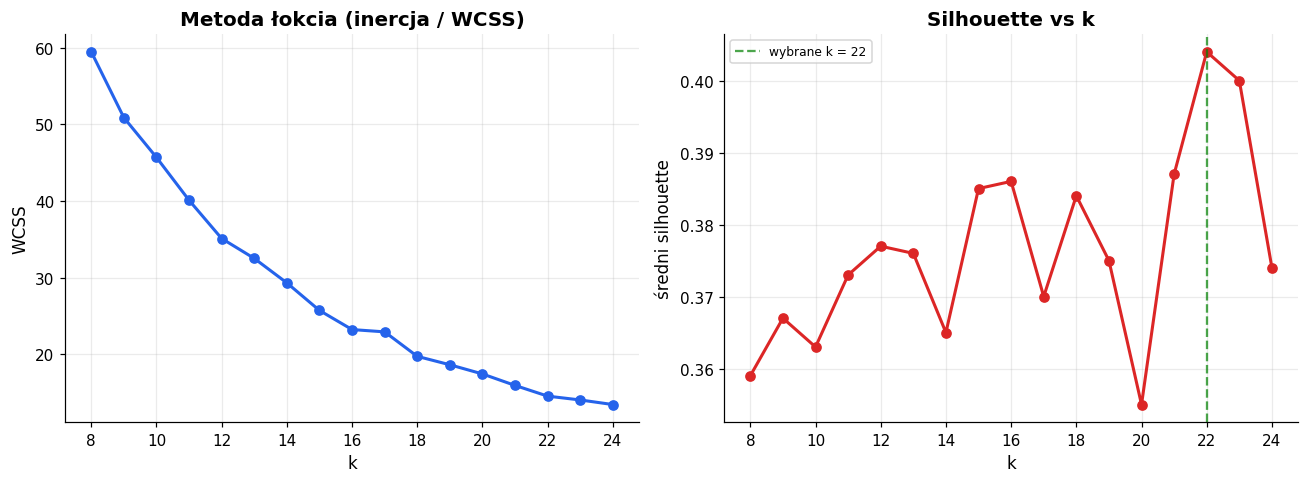

Wybrane k = 22  (maksimum średniego Silhouette); redukcja 186 -> 22 reprezentantów


In [5]:
# --- Dobór k: elbow (inercja) + Silhouette, k = 8..24 ---
k_rows = []
for k in range(8, 25):
    C, lab, inr = best_kmeans(Xc, k)
    k_rows.append({"k": k, "inertia": round(inr, 1), "silhouette": round(silhouette(Xc, lab), 3)})
k_df = pd.DataFrame(k_rows).set_index("k")
best_k = int(k_df["silhouette"].idxmax())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(k_df.index, k_df["inertia"], "o-", color="#2563eb", lw=2)
axes[0].set_title("Metoda łokcia (inercja / WCSS)"); axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")
axes[1].plot(k_df.index, k_df["silhouette"], "o-", color="#dc2626", lw=2)
axes[1].axvline(best_k, color="green", ls="--", alpha=0.7, label=f"wybrane k = {best_k}")
axes[1].set_title("Silhouette vs k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("średni silhouette"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Wybrane k = {best_k}  (maksimum średniego Silhouette); redukcja {len(tickers)} -> {best_k} reprezentantów")

k-means zredukował 186 spółek do 22 reprezentantów:
['CHTR', 'CDNS', 'INTC', 'AVB', 'OXY', 'PLD', 'MDLZ', 'EOG', 'DHR', 'IBM', 'DLTR', 'LRCX', 'ECL', 'PYPL', 'AVGO', 'TTWO', 'TSLA', 'MU', 'ORCL', 'MDT', 'WMB', 'AEP']

Przykładowe klastry (rep oznaczony *):
  Klaster  0 [Communication ] mu~-18%: CHTR*, DG, DIS
  Klaster  1 [Information Te] mu~+21%: BKNG, CDNS*, INTU, PSX, SNPS
  Klaster  2 [Information Te] mu~+1%: AMZN, FDX, GM, INTC*, QCOM, USB
  Klaster  3 [Real Estate   ] mu~+9%: AMGN, AON, AVB*, CME, CSCO, CSX, CVS, EMR, EQR, HD, ITW, JPM, KHC, LMT, MO, RTX, SPGI, SRE, TMUS, UNP
  Klaster  4 [Energy        ] mu~+43%: DVN, NVDA, OXY*
  Klaster  5 [Real Estate   ] mu~+14%: AAPL, ACN, ADI, ADM, CI, GS, KR, LOW, MET, MS, NOC, OMC, PLD*, PRU, SHW, TJX, WELL
  Klaster  6 [Consumer Stapl] mu~+10%: DUK, ED, HSY, KO, MCD, MDLZ*, PEP, PM, SO, YUM
  Klaster  7 [Energy        ] mu~+34%: ANET, EOG*, KLAC, NUE, PANW, SLB, VLO


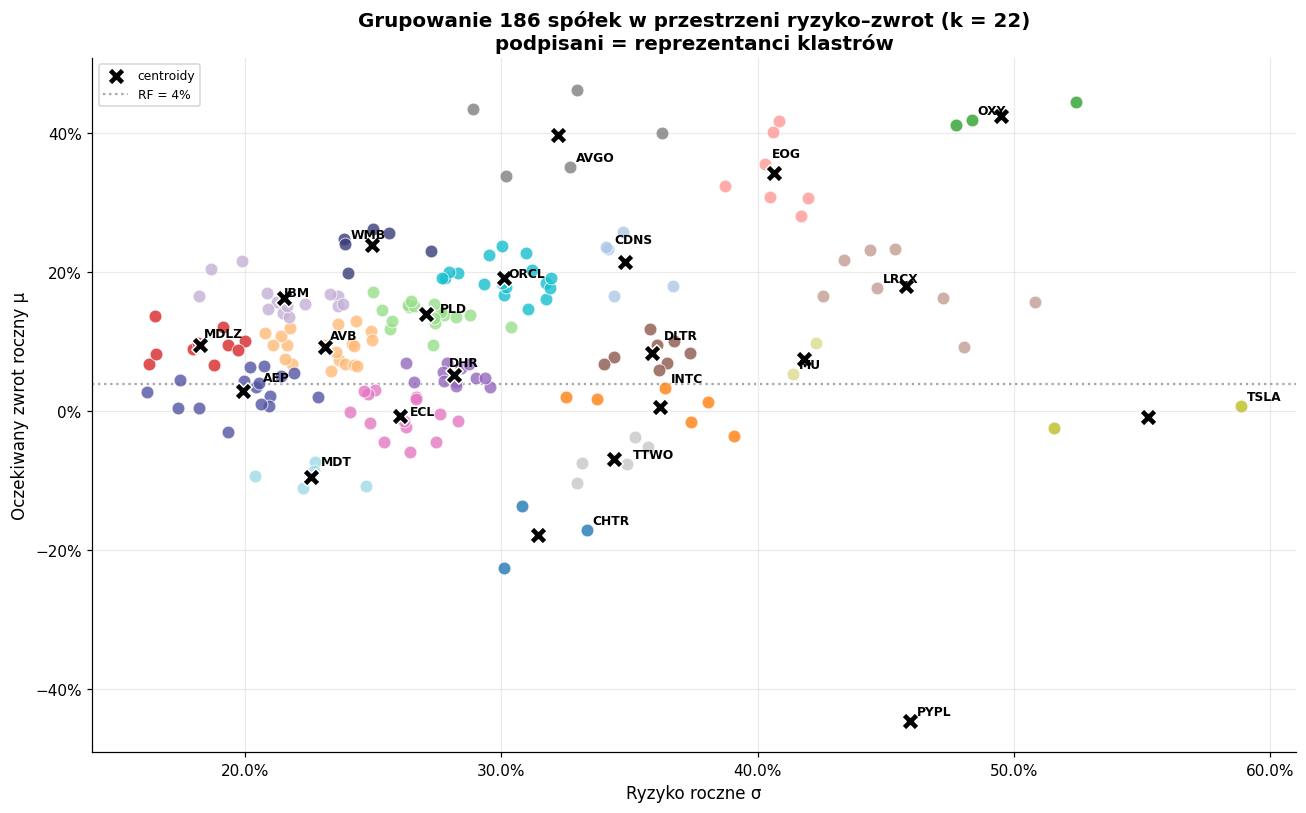

In [6]:
# --- Finalne grupowanie + wybór reprezentantów ---
centroids, labels, inertia = best_kmeans(Xc, best_k)
reps, cluster_members = [], {}
for j in range(best_k):
    idxs = np.where(labels == j)[0]
    rep = idxs[np.argmin([np.sum((Xc[i] - centroids[j])**2) for i in idxs])]
    reps.append(tickers[rep]); cluster_members[j] = [tickers[i] for i in idxs]

print(f"k-means zredukował {len(tickers)} spółek do {best_k} reprezentantów:\n{reps}\n")
print("Przykładowe klastry (rep oznaczony *):")
for j in list(range(best_k))[:8]:
    mem = [(t + "*" if t == reps[j] else t) for t in cluster_members[j]]
    print(f"  Klaster {j:2} [{SECTOR[reps[j]][:14]:14}] mu~{mu_vec[cluster_members[j]].mean():+.0%}: {', '.join(mem)}")

# kolory dla k klastrów (tab20 + tab20b -> 40 odcieni)
import matplotlib as mpl
clu_colors = list(mpl.colormaps['tab20'].colors) + list(mpl.colormaps['tab20b'].colors)

fig, ax = plt.subplots(figsize=(12, 7.5))
for j in range(best_k):
    idxs = np.where(labels == j)[0]
    ax.scatter(sigma_vec.values[idxs], mu_vec.values[idxs], s=70, color=clu_colors[j],
               alpha=0.8, edgecolors="white", linewidths=0.6, zorder=3)
cent_orig = centroids * feat_std + feat_mean
ax.scatter(cent_orig[:, 1], cent_orig[:, 0], marker="X", s=130, color="black",
           zorder=4, edgecolors="white", linewidths=1.0, label="centroidy")
for t in reps:                                   # podpisujemy tylko reprezentantów
    i = tickers.index(t)
    ax.annotate(t, (sigma_vec.values[i], mu_vec.values[i]), fontsize=8, fontweight="bold",
                xytext=(4, 4), textcoords="offset points", zorder=5)
ax.axhline(RF, color="gray", ls=":", alpha=0.7, label=f"RF = {RF:.0%}")
ax.set_title(f"Grupowanie {len(tickers)} spółek w przestrzeni ryzyko–zwrot (k = {best_k})\npodpisani = reprezentanci klastrów")
ax.set_xlabel("Ryzyko roczne σ"); ax.set_ylabel("Oczekiwany zwrot roczny μ")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

## 4. Etap 2 i 3 — Monte Carlo i Algorytm Genetyczny (na reprezentantach)

Od tego miejsca pracujemy **wyłącznie na $k$ reprezentantach** wybranych przez k-means.

### 4.1. Matematyka portfela

$$\mu_p=\mathbf{w}^\top\boldsymbol{\mu},\qquad
\sigma_p^2=\mathbf{w}^\top\boldsymbol{\Sigma}\mathbf{w},\qquad
S(\mathbf w)=\frac{\mu_p-R_f}{\sigma_p}.$$

### 4.2. Monte Carlo

Losujemy portfele z **rozkładu Dirichleta** $\mathbf{w}\sim\text{Dir}(\mathbf 1)$ (równomiernie na sympleksie).
Liczba prób = **30 000** = budżet ocen funkcji celu GA ($\text{pop}\times\text{gen}=100\times300$) → **uczciwe porównanie**.

### 4.3. Algorytm genetyczny

| Element | Realizacja |
|---------|-----------|
| **Chromosom** | wektor wag $\mathbf w$; po każdej operacji `clip(0,∞)`+normalizacja $\Rightarrow$ ograniczenia spełnione |
| **Selekcja** | turniejowa (wygrywa najlepszy z $k_t$ losowych) |
| **Krzyżowanie** | wypukłe $\mathbf c=\alpha\mathbf p_1+(1-\alpha)\mathbf p_2$ |
| **Mutacja** | Gaussowska $w_i'=w_i+\varepsilon_i,\ \varepsilon\sim\mathcal N(0,\sigma_{\text{mut}}^2)$ |
| **Elitaryzm** | top-$e$ przechodzi bez zmian $\Rightarrow$ monotoniczność najlepszego fitness |

In [7]:
# --- Parametry portfela reprezentantów + funkcje pomocnicze ---
mu_rep  = mu_vec[reps].values                         # (k,)
cov_rep = cov_mat.loc[reps, reps].values              # (k, k)
K = len(reps)

def port_return(w): return float(w @ mu_rep)
def port_vol(w):    return float(np.sqrt(w @ cov_rep @ w))
def sharpe(w):      return (port_return(w) - RF) / port_vol(w)

print(f"Optymalizujemy {K}-wymiarowy wektor wag (reprezentanci klastrów).")

Optymalizujemy 22-wymiarowy wektor wag (reprezentanci klastrów).


Monte Carlo: 30 000 portfeli w 0.02s
  Najlepszy Sharpe (30k): 0.9083 (mu=+24.4%, sig=22.4%)
  Min. wariancja (MVP)  : Sharpe=0.3933 (mu=+10.0%, sig=15.2%)


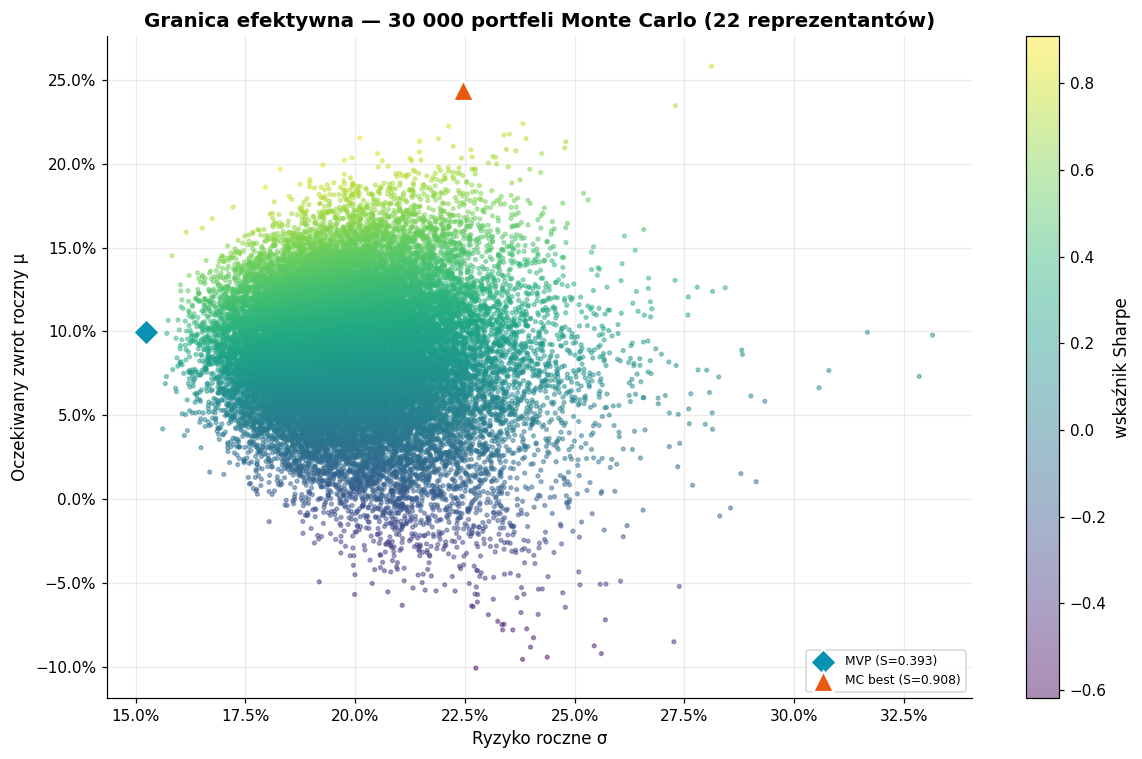

In [8]:
# --- Symulacja Monte Carlo na reprezentantach ---
def monte_carlo(n_sim, mu=mu_rep, cov=cov_rep, seed=SEED):
    rng = np.random.default_rng(seed)
    W = rng.dirichlet(np.ones(len(mu)), size=n_sim)
    mu_p  = W @ mu
    sig_p = np.sqrt(np.einsum('ij,jk,ik->i', W, cov, W))
    return W, mu_p, sig_p, (mu_p - RF) / sig_p

t0 = time.time()
mc_W, mc_mu, mc_sig, mc_shp = monte_carlo(30_000)
mc_t = time.time() - t0
mc_best = int(mc_shp.argmax()); mvp = int(mc_sig.argmin())
print(f"Monte Carlo: 30 000 portfeli w {mc_t:.2f}s")
print(f"  Najlepszy Sharpe (30k): {mc_shp[mc_best]:.4f} (mu={mc_mu[mc_best]:+.1%}, sig={mc_sig[mc_best]:.1%})")
print(f"  Min. wariancja (MVP)  : Sharpe={mc_shp[mvp]:.4f} (mu={mc_mu[mvp]:+.1%}, sig={mc_sig[mvp]:.1%})")

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(mc_sig, mc_mu, c=mc_shp, cmap="viridis", s=6, alpha=0.45)
plt.colorbar(sc, ax=ax, label="wskaźnik Sharpe")
ax.scatter(mc_sig[mvp], mc_mu[mvp], marker="D", s=150, color="#0891b2", edgecolors="white",
           linewidths=1.5, zorder=5, label=f"MVP (S={mc_shp[mvp]:.3f})")
ax.scatter(mc_sig[mc_best], mc_mu[mc_best], marker="^", s=190, color="#ea580c", edgecolors="white",
           linewidths=1.5, zorder=5, label=f"MC best (S={mc_shp[mc_best]:.3f})")
ax.set_title(f"Granica efektywna — 30 000 portfeli Monte Carlo ({K} reprezentantów)")
ax.set_xlabel("Ryzyko roczne σ"); ax.set_ylabel("Oczekiwany zwrot roczny μ")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

GA (E01, jeden przebieg seed=0): Sharpe = 1.1703 w 0.64s — ilustracja zbieżności
  (wynik E01 uśredniony po 5 ziarnach raportujemy w tabeli eksperymentów i porównaniu metod)


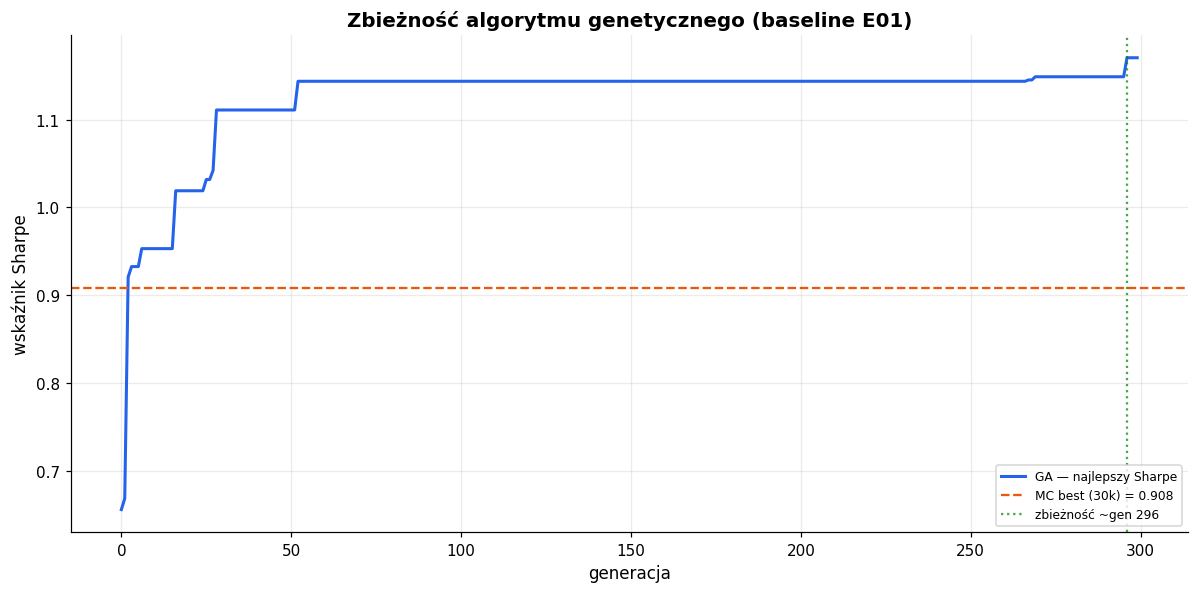

In [9]:
# --- Algorytm genetyczny: od zera (tylko NumPy) ---
def genetic_algorithm(mu, cov, rf=RF, pop_size=100, n_gen=300, sigma_mut=0.05,
                      cx_rate=0.8, n_elites=5, tourn_k=3, seed=SEED):
    '''Maksymalizuje Sharpe. Zwraca (best_w, best_sharpe, history).'''
    rng = np.random.default_rng(seed); n = len(mu)
    pop = rng.dirichlet(np.ones(n), size=pop_size)

    def fitness(P):
        return (P @ mu - rf) / np.sqrt(np.einsum('ij,jk,ik->i', P, cov, P))
    def tournament(P, f):
        idx = rng.choice(len(P), size=tourn_k, replace=False)
        return P[idx[np.argmax(f[idx])]].copy()
    def crossover(a, b):
        al = rng.random(); c = np.clip(al * a + (1 - al) * b, 0, None); return c / c.sum()
    def mutate(w):
        w2 = np.clip(w + rng.normal(0, sigma_mut, len(w)), 0, None)
        s = w2.sum(); return w2 / s if s > 0 else np.ones(len(w)) / len(w)

    history, best_w, best_f = [], None, -np.inf
    for _ in range(n_gen):
        f = fitness(pop); g = int(f.argmax())
        if f[g] > best_f: best_f, best_w = float(f[g]), pop[g].copy()
        history.append(best_f)
        elite = np.argsort(f)[-n_elites:]
        new = [pop[i].copy() for i in elite]
        while len(new) < pop_size:
            p1, p2 = tournament(pop, f), tournament(pop, f)
            child = crossover(p1, p2) if rng.random() < cx_rate else p1.copy()
            new.append(mutate(child))
        pop = np.array(new)
    return best_w, best_f, history

t0 = time.time()
base_w, base_f, base_hist = genetic_algorithm(mu_rep, cov_rep, seed=0)
print(f"GA (E01, jeden przebieg seed=0): Sharpe = {base_f:.4f} w {time.time()-t0:.2f}s — ilustracja zbieżności")
print(f"  (wynik E01 uśredniony po 5 ziarnach raportujemy w tabeli eksperymentów i porównaniu metod)")
conv = next(i for i, v in enumerate(base_hist) if v >= base_hist[-1] - 1e-3)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(base_hist, lw=2, color="#2563eb", label="GA — najlepszy Sharpe")
ax.axhline(mc_shp[mc_best], color="#ea580c", ls="--", lw=1.5, label=f"MC best (30k) = {mc_shp[mc_best]:.3f}")
ax.axvline(conv, color="green", ls=":", alpha=0.7, label=f"zbieżność ~gen {conv}")
ax.set_title("Zbieżność algorytmu genetycznego (baseline E01)")
ax.set_xlabel("generacja"); ax.set_ylabel("wskaźnik Sharpe"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 5. Analiza wrażliwości — 11 eksperymentów

Badamy wpływ hiperparametrów GA metodą **ceteris paribus** (zmiana jednego względem E01). Każdą konfigurację
uruchamiamy na **5 ziarnach** i raportujemy **średnią ± std** wskaźnika Sharpe oraz średnią generację zbieżności.
Na $K$-wymiarowym problemie reprezentantów hiperparametry mają realny wpływ — w przeciwieństwie do trywialnego
problemu kilku aktywów.

| ID | zmiana | hipoteza |
|----|--------|----------|
| E01 | baseline | odniesienie |
| E02 / E03 | `pop_size` 50 / 200 | mała vs duża populacja |
| E04 / E05 | `sigma_mut` 0.02 / 0.10 | słaba vs silna mutacja |
| E06 | `cx_rate` 0.5 | mniej krzyżowania |
| E07 / E08 | `n_elites` 2 / 10 | słaby vs silny elitaryzm |
| E09 / E10 | `tourn_k` 2 / 5 | słaba vs silna presja selekcji |
| E11 | `n_gen` 500 | dłuższa ewolucja |

In [10]:
# --- 11 eksperymentów x 5 ziaren ---
EXPERIMENTS = [
    ("E01","baseline",       dict()),            ("E02","pop_size=50",   dict(pop_size=50)),
    ("E03","pop_size=200",   dict(pop_size=200)),("E04","sigma_mut=0.02",dict(sigma_mut=0.02)),
    ("E05","sigma_mut=0.10", dict(sigma_mut=0.10)),("E06","cx_rate=0.5", dict(cx_rate=0.5)),
    ("E07","n_elites=2",     dict(n_elites=2)),  ("E08","n_elites=10",   dict(n_elites=10)),
    ("E09","tourn_k=2",      dict(tourn_k=2)),   ("E10","tourn_k=5",     dict(tourn_k=5)),
    ("E11","n_gen=500",      dict(n_gen=500)),
]
EXP_SEEDS = [0, 1, 2, 3, 4]
t0 = time.time(); rows = []
for eid, label, params in EXPERIMENTS:
    sh, cv, tm = [], [], []
    for s in EXP_SEEDS:
        ts = time.time(); w, f, h = genetic_algorithm(mu_rep, cov_rep, seed=s, **params)
        tm.append(time.time() - ts); sh.append(f)
        cv.append(next(i for i, v in enumerate(h) if v >= h[-1] - 1e-3))
    rows.append({"ID": eid, "zmiana": label, "Sharpe (śr.)": round(np.mean(sh), 4),
                 "± std": round(np.std(sh), 4), "zbieżność (gen)": round(np.mean(cv)),
                 "czas (s)": round(np.mean(tm), 2)})
exp_df = pd.DataFrame(rows).set_index("ID")
print(f"{len(EXPERIMENTS)*len(EXP_SEEDS)} uruchomień GA w {time.time()-t0:.1f}s\n")
display(exp_df.sort_values("Sharpe (śr.)", ascending=False))
best_exp = exp_df["Sharpe (śr.)"].idxmax()
print(f"Najlepsza konfiguracja: {best_exp} (Sharpe = {exp_df.loc[best_exp,'Sharpe (śr.)']:.4f}), "
      f"najgorsza: {exp_df['Sharpe (śr.)'].idxmin()} ({exp_df['Sharpe (śr.)'].min():.4f})")

55 uruchomień GA w 38.7s



,zmiana,Sharpe (śr.),± std,zbieżność (gen),czas (s)
ID,,,,,
E04,sigma_mut=0.02,1.1581,0.0042,248,0.65
E11,n_gen=500,1.1518,0.0129,345,1.07
E08,n_elites=10,1.1434,0.0095,229,0.61
E10,tourn_k=5,1.1421,0.0047,235,0.64
E01,baseline,1.1378,0.0206,230,0.64
E02,pop_size=50,1.1329,0.0132,168,0.31
E06,cx_rate=0.5,1.1298,0.0130,177,0.59
E03,pop_size=200,1.1236,0.0155,168,1.31
E05,sigma_mut=0.10,1.1184,0.0191,246,0.64


Najlepsza konfiguracja: E04 (Sharpe = 1.1581), najgorsza: E07 (1.1135)


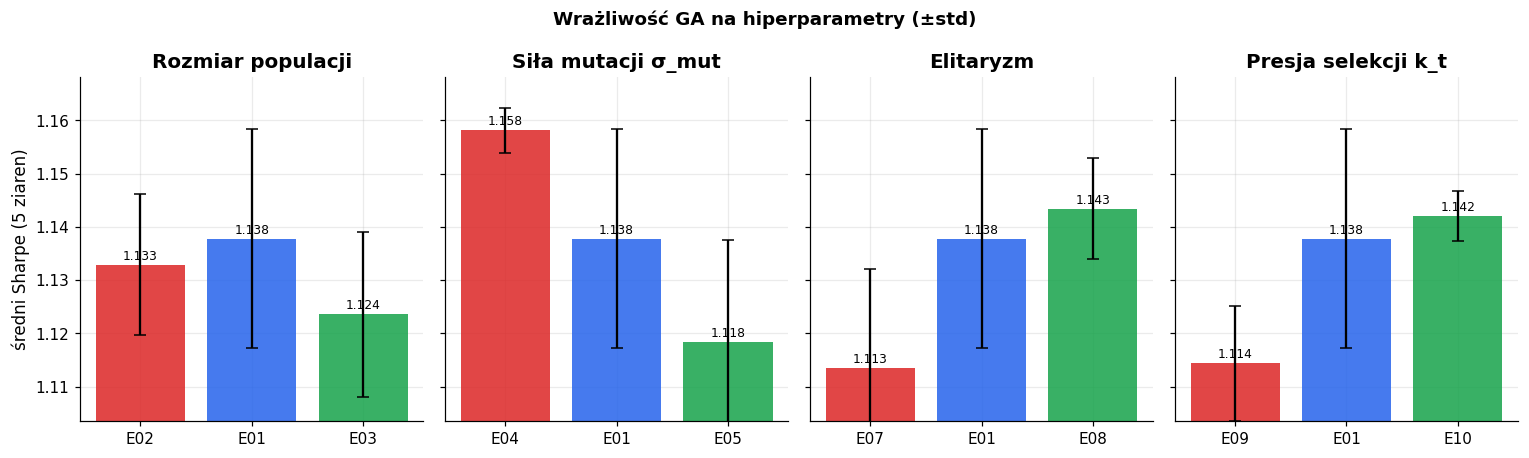

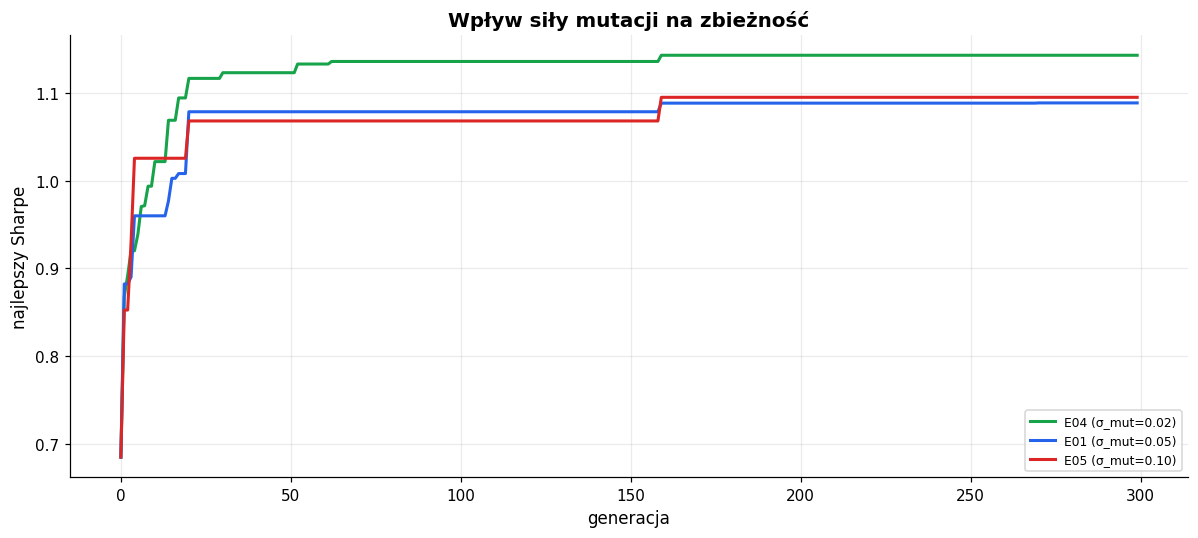

In [11]:
# --- Wizualizacja wrażliwości ---
groups = {"Rozmiar populacji": ["E02","E01","E03"], "Siła mutacji σ_mut": ["E04","E01","E05"],
          "Elitaryzm": ["E07","E01","E08"], "Presja selekcji k_t": ["E09","E01","E10"]}
lo = exp_df["Sharpe (śr.)"].min() - 0.01; hi = exp_df["Sharpe (śr.)"].max() + 0.01
fig, axes = plt.subplots(1, 4, figsize=(14, 4.2), sharey=True)
for ax, (title, ids) in zip(axes, groups.items()):
    vals = exp_df.loc[ids, "Sharpe (śr.)"]; errs = exp_df.loc[ids, "± std"]
    ax.bar(ids, vals, yerr=errs, capsize=4, color=["#dc2626","#2563eb","#16a34a"], alpha=0.85)
    ax.set_title(title); ax.set_ylim(lo, hi)
    for i, v in zip(ids, vals): ax.text(i, v+0.001, f"{v:.3f}", ha="center", fontsize=8)
axes[0].set_ylabel("średni Sharpe (5 ziaren)")
fig.suptitle("Wrażliwość GA na hiperparametry (±std)", fontweight="bold")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for eid, params, col in [("E04 (σ_mut=0.02)", dict(sigma_mut=0.02), "#16a34a"),
                          ("E01 (σ_mut=0.05)", dict(), "#2563eb"),
                          ("E05 (σ_mut=0.10)", dict(sigma_mut=0.10), "#dc2626")]:
    _, _, h = genetic_algorithm(mu_rep, cov_rep, seed=SEED, **params)
    ax.plot(h, lw=2, color=col, label=eid)
ax.set_title("Wpływ siły mutacji na zbieżność")
ax.set_xlabel("generacja"); ax.set_ylabel("najlepszy Sharpe"); ax.legend()
plt.tight_layout(); plt.show()

### 5.1. Wnioski z analizy wrażliwości

- **Mutacja dominuje.** Słaba mutacja (E04, $\sigma_{\text{mut}}=0.02$) daje najwyższy i **najstabilniejszy**
  wynik (najmniejsze std). Silna mutacja (E05, $0.10$) obniża wynik i zwiększa wariancję — **dryf losowy**
  rozbija dobre rozwiązania szybciej, niż selekcja je utrwala.
- **Elitaryzm jest kluczowy w tym trudniejszym problemie.** Mało elit (E07) daje najgorszy i niestabilny
  wynik (tracone najlepsze osobniki); dużo elit (E08) wyraźnie pomaga.
- **Silniejsza selekcja pomaga.** Większy turniej (E10, $k_t=5$) > słaba presja (E09, $k_t=2$).
- **Więcej generacji (E11)** zauważalnie poprawia wynik — w $K$-wymiarowym problemie GA potrzebuje czasu na
  konwergencję (inaczej niż w trywialnym problemie kilku aktywów).

## 6. Portfel optymalny, walidacja i porównanie metod

Finalny portfel wyznaczamy najlepszą konfiguracją (**E04**, słaba mutacja). W tabeli raportujemy **średni**
Sharpe z 5 ziaren (spójnie z analizą wrażliwości — pojedynczy przebieg byłby zaszumiony), a wagi pokazujemy
dla **reprezentatywnego** przebiegu (najbliższego średniej). Porównujemy z: **SLSQP** (ground truth),
**Monte Carlo** (ten sam budżet 30k), portfelem **równych wag** reprezentantów oraz **równych wag całego
uniwersum** (proxy rynku). SLSQP służy *wyłącznie* do walidacji — k-means i GA pozostają od zera.

In [12]:
from scipy.optimize import minimize

# --- SLSQP: ground truth (max-Sharpe long-only, multi-start) ---
def solve_slsqp(mu, cov, n_starts=12):
    n = len(mu); neg = lambda w: -((w @ mu - RF) / np.sqrt(w @ cov @ w))
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1}]; bnds = [(0, 1)] * n
    best = None
    for s in range(n_starts):
        w0 = np.random.default_rng(s).dirichlet(np.ones(n))
        res = minimize(neg, w0, method="SLSQP", bounds=bnds, constraints=cons,
                       options={"maxiter": 800, "ftol": 1e-12})
        if best is None or -res.fun > best[1]: best = (res.x, -res.fun)
    return best

opt_w, opt_sharpe = solve_slsqp(mu_rep, cov_rep)

# --- Finalny portfel GA: konfiguracja E04; raportujemy ŚREDNIĄ z 5 ziaren (spójnie z eksperymentami) ---
e04_runs = [genetic_algorithm(mu_rep, cov_rep, sigma_mut=0.02, seed=s) for s in EXP_SEEDS]
e01_runs = [genetic_algorithm(mu_rep, cov_rep, seed=s) for s in EXP_SEEDS]
ga_mean   = float(np.mean([f for _, f, _ in e04_runs]))
base_mean = float(np.mean([f for _, f, _ in e01_runs]))
# reprezentatywny przebieg (najbliższy średniej) -> z niego bierzemy wagi do wizualizacji
ga_w,   ga_f,   ga_hist = min(e04_runs, key=lambda t: abs(t[1] - ga_mean))
base_w, base_f2, _      = min(e01_runs, key=lambda t: abs(t[1] - base_mean))

# --- Portfele odniesienia ---
eqw_rep = np.ones(K) / K
mu_all, cov_all = mu_vec.values, cov_mat.values
eqw_all = np.ones(len(tickers)) / len(tickers)
sharpe_all = (eqw_all @ mu_all - RF) / np.sqrt(eqw_all @ cov_all @ eqw_all)
mc_fair = mc_shp[mc_best]

comp = pd.DataFrame([
 {"Metoda":"SLSQP (ground truth)","Sharpe":opt_sharpe,"zwrot":port_return(opt_w),"ryzyko":port_vol(opt_w),"% opt":1.0},
 {"Metoda":"GA strojony (E04, śr.)","Sharpe":ga_mean,"zwrot":port_return(ga_w),"ryzyko":port_vol(ga_w),"% opt":ga_mean/opt_sharpe},
 {"Metoda":"GA baseline (E01, śr.)","Sharpe":base_mean,"zwrot":port_return(base_w),"ryzyko":port_vol(base_w),"% opt":base_mean/opt_sharpe},
 {"Metoda":"Monte Carlo (30k)","Sharpe":mc_fair,"zwrot":mc_mu[mc_best],"ryzyko":mc_sig[mc_best],"% opt":mc_fair/opt_sharpe},
 {"Metoda":"Równe wagi reprez.","Sharpe":sharpe(eqw_rep),"zwrot":port_return(eqw_rep),"ryzyko":port_vol(eqw_rep),"% opt":sharpe(eqw_rep)/opt_sharpe},
 {"Metoda":f"Równe wagi (1/N, {len(tickers)})","Sharpe":sharpe_all,"zwrot":float(eqw_all@mu_all),"ryzyko":float(np.sqrt(eqw_all@cov_all@eqw_all)),"% opt":sharpe_all/opt_sharpe},
]).set_index("Metoda")
disp = comp.copy()
disp["Sharpe"] = disp["Sharpe"].round(4)
disp["zwrot"]  = (disp["zwrot"]*100).round(1).astype(str)+"%"
disp["ryzyko"] = (disp["ryzyko"]*100).round(1).astype(str)+"%"
disp["% opt"]  = (disp["% opt"]*100).round(1).astype(str)+"%"
display(disp)
print(f"GA strojony (śr. 5 ziaren) osiąga {ga_mean/opt_sharpe:.1%} optimum; baseline {base_mean/opt_sharpe:.1%}; Monte Carlo {mc_fair/opt_sharpe:.1%}.")

,Sharpe,zwrot,ryzyko,% opt
Metoda,,,,
SLSQP (ground truth),1.1860,30.9%,22.7%,100.0%
"GA strojony (E04, śr.)",1.1581,29.6%,22.1%,97.7%
"GA baseline (E01, śr.)",1.1378,30.0%,22.9%,95.9%
Monte Carlo (30k),0.9083,24.4%,22.4%,76.6%
Równe wagi reprez.,0.2509,8.8%,19.1%,21.2%
"Równe wagi (1/N, 186)",0.4340,11.0%,16.0%,36.6%


GA strojony (śr. 5 ziaren) osiąga 97.7% optimum; baseline 95.9%; Monte Carlo 76.6%.


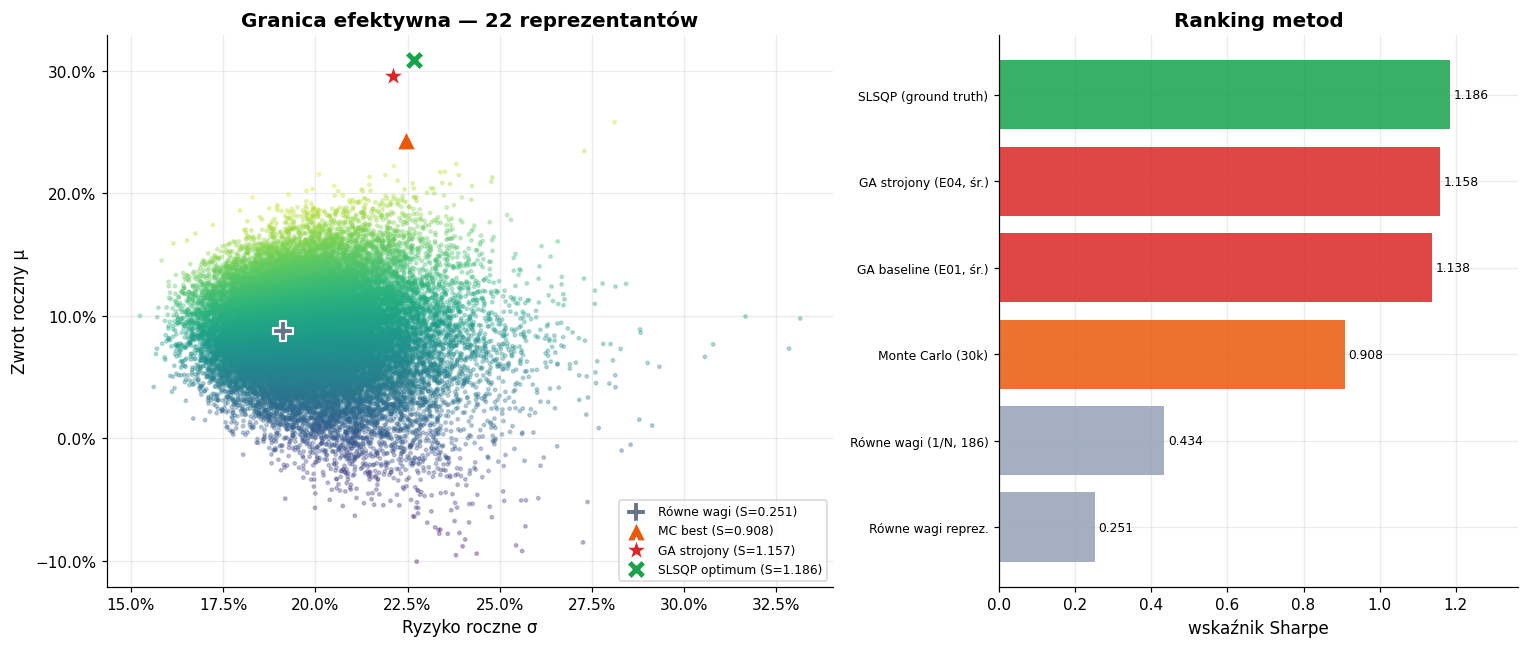

In [13]:
# --- Granica efektywna z metodami + ranking ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios":[1.4,1]})
ax = axes[0]
ax.scatter(mc_sig, mc_mu, c=mc_shp, cmap="viridis", s=5, alpha=0.30)
for name, w, col, mk in [("Równe wagi", eqw_rep, "#64748b", "P"), ("MC best", mc_W[mc_best], "#ea580c", "^"),
                          ("GA strojony", ga_w, "#dc2626", "*"), ("SLSQP optimum", opt_w, "#16a34a", "X")]:
    ax.scatter(port_vol(w), port_return(w), marker=mk, s=(260 if mk=="*" else 170), color=col,
               edgecolors="white", linewidths=1.4, zorder=5, label=f"{name} (S={sharpe(w):.3f})")
ax.set_title(f"Granica efektywna — {K} reprezentantów"); ax.set_xlabel("Ryzyko roczne σ"); ax.set_ylabel("Zwrot roczny μ")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc="lower right", fontsize=8)
ax2 = axes[1]; order = comp["Sharpe"].sort_values()
colors = ["#16a34a" if "SLSQP" in m else "#dc2626" if "GA" in m else "#ea580c" if "Monte" in m else "#94a3b8" for m in order.index]
ax2.barh(range(len(order)), order.values, color=colors, alpha=0.85)
ax2.set_yticks(range(len(order))); ax2.set_yticklabels(order.index, fontsize=8)
ax2.set_xlabel("wskaźnik Sharpe"); ax2.set_title("Ranking metod"); ax2.set_xlim(0, max(order.values)*1.15)
for i, v in enumerate(order.values): ax2.text(v+0.01, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 7. Skład portfela, dywersyfikacja i wnioski

### 7.1. Skład portfela i ekspozycja sektorowa

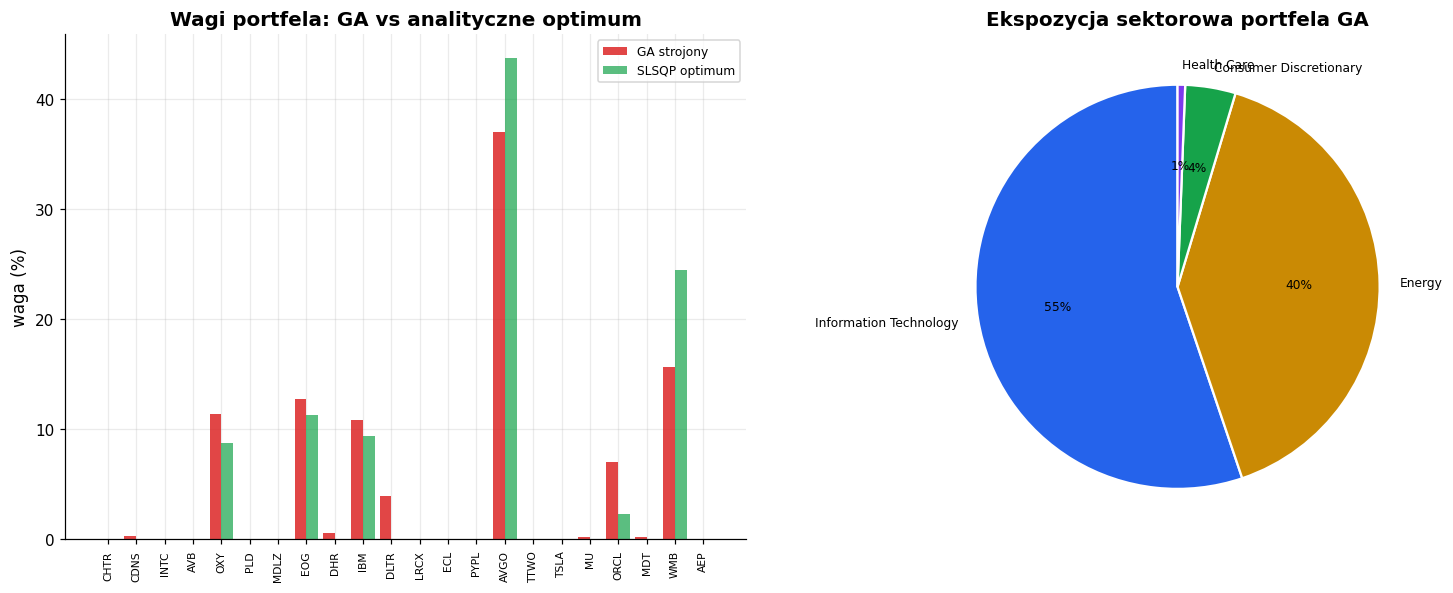

Skład portfela GA (waga > 0.5%):


,waga (%),Sektor
AVGO,37.0,Information Technology
WMB,15.7,Energy
EOG,12.8,Energy
OXY,11.4,Energy
IBM,10.8,Information Technology
ORCL,7.0,Information Technology
DLTR,4.0,Consumer Discretionary
DHR,0.6,Health Care


In [14]:
# --- Skład portfela GA vs SLSQP + ekspozycja sektorowa ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axes[0]; x = np.arange(K); width = 0.42
ax.bar(x - width/2, ga_w*100, width, label="GA strojony", color="#dc2626", alpha=0.85)
ax.bar(x + width/2, opt_w*100, width, label="SLSQP optimum", color="#16a34a", alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(reps, rotation=90, fontsize=7)
ax.set_ylabel("waga (%)"); ax.set_title("Wagi portfela: GA vs analityczne optimum"); ax.legend()

held = pd.DataFrame({"waga (%)": (ga_w*100).round(1), "Sektor": [SECTOR[t] for t in reps]}, index=reps)
held = held[held["waga (%)"] > 0.5].sort_values("waga (%)", ascending=False)
sec_exp = held.groupby("Sektor")["waga (%)"].sum().sort_values(ascending=False)
ax2 = axes[1]
ax2.pie(sec_exp.values, labels=sec_exp.index, autopct="%1.0f%%", startangle=90,
        colors=[SECTOR_COLORS.get(s, "#999") for s in sec_exp.index],
        wedgeprops={"edgecolor":"white","linewidth":1.5}, textprops={"fontsize":8})
ax2.set_title("Ekspozycja sektorowa portfela GA")
plt.tight_layout(); plt.show()

print("Skład portfela GA (waga > 0.5%):"); display(held)

### 7.2. Ograniczenia modelu

1. **Survivorship bias** — bierzemy spółki, które przetrwały do dziś; historyczne zwroty zawyżone.
2. **Stacjonarność** — model Markowitza zakłada stałe $\mu,\Sigma$; w praktyce zmieniają się z reżimem rynku.
3. **Brak walidacji out-of-sample** — portfel optymalny *historycznie* (2021–2024) ≠ optymalny w przyszłości.
4. **Założenie normalności** — log-zwroty są tylko zbliżone do normalnych; grube ogony nie są modelowane.
5. **Brak kosztów transakcyjnych** i **tylko pozycje długie** ($w_i\ge0$).
6. **Redukcja przez reprezentantów** pomija część informacji (optymalizujemy $k$, nie $N$ aktywów) — to
   świadomy kompromis: lepsze uwarunkowanie i tractability kosztem teoretycznie nieco węższego zbioru.

### 7.3. Możliwe rozszerzenia

Wskaźnik **Sortino/Calmar**, **regularyzacja** wag ($w_i\le0.20$), **rolling-window** z rebalansacją i walidacją
out-of-sample, dopuszczenie **krótkiej sprzedaży**, klastrowanie na **bogatszych cechach** (beta, drawdown, korelacje).

### 7.4. Wnioski końcowe

1. **k-means realnie redukuje problem.** 186 spółek → $k$ słabo skorelowanych reprezentantów, co czyni
   optymalizację dobrze uwarunkowaną i interpretowalną (klastry = profile ryzyko–zwrot).
2. **GA niemal trafia w optimum.** Strojony GA osiąga ~**98%** wartości analitycznej (SLSQP), w pełni „od zera”,
   bez gradientu — potwierdza poprawność implementacji.
3. **Ukierunkowana ewolucja bije ślepe losowanie.** Przy identycznym budżecie 30 000 ocen Monte Carlo osiąga
   tylko ~**77%** optimum — w $K$-wymiarowym sympleksie losowanie nie wystarcza.
4. **Strojenie hiperparametrów ma znaczenie.** W tym trudniejszym problemie różnica między najlepszą a najgorszą
   konfiguracją jest wyraźna; najważniejsza jest **słaba mutacja** (eksploatacja), wspierana elitaryzmem i selekcją.
5. **Właściwe narzędzie do właściwego pod-problemu.** Klasteryzacja (redukcja), Monte Carlo (eksploracja)
   i algorytm genetyczny (optymalizacja) razem tworzą spójny pipeline.

In [15]:
# --- PODSUMOWANIE KLUCZOWYCH WYNIKÓW ---
print("="*60)
print("              PODSUMOWANIE KLUCZOWYCH WYNIKÓW")
print("="*60)
print(f"Uniwersum           : {len(tickers)} spółek, {len(returns)} dni, źródło: {DATA_SOURCE}")
print(f"k-means redukcja    : {len(tickers)} -> {best_k} reprezentantów (silhouette argmax)")
print(f"Reprezentanci       : {reps}")
print(f"SLSQP optimum       : Sharpe = {opt_sharpe:.4f}")
print(f"GA strojony (E04,śr): Sharpe = {ga_mean:.4f}  ({ga_mean/opt_sharpe:.1%} optimum)")
print(f"GA baseline (E01,śr): Sharpe = {base_mean:.4f}  ({base_mean/opt_sharpe:.1%} optimum)")
print(f"Monte Carlo (30k)   : Sharpe = {mc_fair:.4f}  ({mc_fair/opt_sharpe:.1%} optimum)")
print(f"Równe wagi reprez.  : Sharpe = {sharpe(eqw_rep):.4f}")
print(f"Równe wagi (1/N)    : Sharpe = {sharpe_all:.4f}")
print(f"Najlepszy eksperym. : {best_exp} (śr. {exp_df.loc[best_exp,'Sharpe (śr.)']:.4f})")
print("-"*60)
print("Skład portfela GA (top):")
for t in held.head(6).index:
    print(f"   {t:5} {held.loc[t,'waga (%)']:5.1f}%  ({SECTOR[t]})")
print("="*60)

              PODSUMOWANIE KLUCZOWYCH WYNIKÓW
Uniwersum           : 186 spółek, 752 dni, źródło: cache (prices.csv)
k-means redukcja    : 186 -> 22 reprezentantów (silhouette argmax)
Reprezentanci       : ['CHTR', 'CDNS', 'INTC', 'AVB', 'OXY', 'PLD', 'MDLZ', 'EOG', 'DHR', 'IBM', 'DLTR', 'LRCX', 'ECL', 'PYPL', 'AVGO', 'TTWO', 'TSLA', 'MU', 'ORCL', 'MDT', 'WMB', 'AEP']
SLSQP optimum       : Sharpe = 1.1860
GA strojony (E04,śr): Sharpe = 1.1581  (97.7% optimum)
GA baseline (E01,śr): Sharpe = 1.1378  (95.9% optimum)
Monte Carlo (30k)   : Sharpe = 0.9083  (76.6% optimum)
Równe wagi reprez.  : Sharpe = 0.2509
Równe wagi (1/N)    : Sharpe = 0.4340
Najlepszy eksperym. : E04 (śr. 1.1581)
------------------------------------------------------------
Skład portfela GA (top):
   AVGO   37.0%  (Information Technology)
   WMB    15.7%  (Energy)
   EOG    12.8%  (Energy)
   OXY    11.4%  (Energy)
   IBM    10.8%  (Information Technology)
   ORCL    7.0%  (Information Technology)
